In [ ]:
pip install pandas scikit-learn 

In [22]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Load datasets
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

# Add labels
fake["label"] = "fake"
true["label"] = "real"

# Combine datasets
data = pd.concat([fake, true], axis=0)

# Shuffle data
data = data.sample(frac=1, random_state=42)

# Combine title + text
data["content"] = data["title"] + " " + data["text"]

# Features & labels
X = data["content"]
y = data["label"]

# TF-IDF
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.7,
    ngram_range=(1,2)
)

X_vectorized = vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42, stratify=y
)

# Model
model = LinearSVC()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9947661469933184


In [23]:
news = ["Breaking: Government announces new economic policy"]

news_vector = vectorizer.transform(news)
prediction = model.predict(news_vector)

print("Prediction:", prediction[0])

Prediction: fake


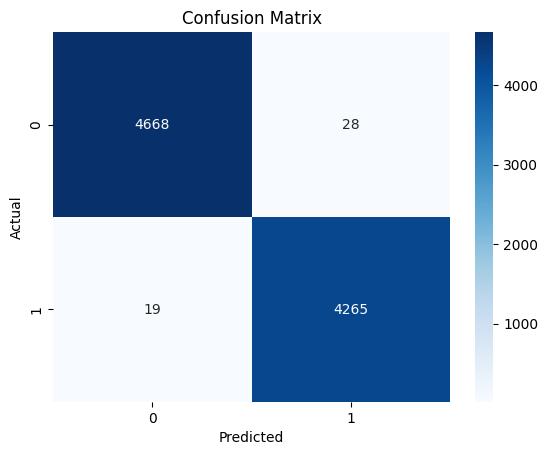

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
import pickle

pickle.dump(model, open("fake_news_model.pkl", "wb"))
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))